In [1]:
import matplotlib.pyplot as plt
import numpy as np
import copy

# Check if lines intersect

In [2]:
def check_intersection(a1, a2, b1, b2):
    # Check if two lines (a1->a2 and b1->b2) intersect. If the lines make a 
    # T or a V, then this is flagged. num_tols=1: T, num_tols=2: V. If the lines match, 
    # this just gets counted as non-intersecting
    tol = 1e-8

    
    # Direction vectors for the lines
    e =   a2-a1
    f = -(b2-b1)

    # distance vector between initial points
    g = b1-a1
    
    M = np.array([[e[0], f[0]],[e[1], f[1]]])
    det = np.linalg.det(M)

    # If the direction vectors are parallel, then M has zero determinant
    # and the lines will not intersect
    if np.abs(det) < tol:
        return False, 0

    t,s = np.linalg.inv(M)@g

    num_tols = 0
    if -tol<t<tol or 1-tol<t<1+tol:
        num_tols += 1

    if -tol<s<tol or 1-tol<s<1+tol:
        num_tols += 1
    
    # print(t,s)
    return bool(-tol<t<1+tol and -tol<s<1+tol), num_tols

# Check if lines coincide

In [3]:
def lines_coincide(a,b,c,d):
    tol = 1e-8

    # Setup coordinate system on line segment a-b
    v = b-a
    u = np.array([-v[1], v[0]])
    v2 = v@v

    # the perpendicular component to a-b must be zero
    if abs(c@u) > tol or abs(d@u) > tol:
        return False

    return -tol < c@v < v2+tol or -tol < d@v < v2+tol
    

# Get angle

In [4]:
def get_angle(v1, v2):
    # get the angle between the vectors v1, v2
    cosine = np.dot(v1, v2)/np.linalg.norm(v1)/np.linalg.norm(v2)

    
    if cosine > 1.0: 
        return 0.0
    elif cosine < -1:
        return 180.0
    else:
        return float(np.arccos(cosine)*180/np.pi)
    



# Node, state and polygon classes

In [5]:
class Node:
    def __init__(self, position, angle_init, angle_opening):
        self.position = np.array(position)
        self.angle_init = angle_init
        self.angle_opening = angle_opening
    


In [6]:
class Polygon:

    def is_outside_bounds(self):
        tol = 1e-8
        # Check if it does not go out of bounds
        outside = False
        for v in self.vertices:
            # print(v)
            if v[0] < -tol or v[0] > 12+tol or v[1] < -tol or v[1] > 12+tol:
                outside = True
                break
                
        return outside

    def post_vertices(self):
        # pre-calculate some new quantities from the vertices
        
        self.vertices_x = [v[0] for v in self.vertices]
        self.vertices_y = [v[1] for v in self.vertices]
        
        self.verticese_x = [v[0] for v in self.vertices] + [self.vertices[0][0]]
        self.verticese_y = [v[1] for v in self.vertices] + [self.vertices[0][1]]

        self.edges = []
        for i in range(self.Nsides):
            r1 = self.vertices[i]
            r2 = self.vertices[(i+1)%self.Nsides]
            self.edges.append([r1,r2])
            

    def reflect(self):
        self.vertices = [np.array([12-v[0], v[1]]) for v in self.vertices][::-1]
        self.post_vertices()
        self.get_angles()

        
    def rotate_around_point(self, angle, point):
        angle_rad = angle*np.pi/180
        rot_matrix = np.array([[ np.cos(angle_rad), np.sin(angle_rad)],
                               [-np.sin(angle_rad), np.cos(angle_rad)]])

        self.vertices   = [rot_matrix@(r-point) + point for r in self.vertices]
        self.post_vertices()

    def translate(self, dr):

        self.vertices   = [r+dr for r in self.vertices]
        self.post_vertices()


    def get_crossings(self, r3,r4):

        num_intersections = 0
        num_tols = 0
        for edge in self.edges:
            r1, r2 = edge
            intersected, tols = check_intersection(r1, r2, r3, r4)
            num_tols += tols
            if intersected:
                num_intersections += 1

        return num_intersections, num_tols

    def is_inside(self, r):
        origin = np.array([-1,-1.1])
        num_intersections, num_tols = self.get_crossings(r, origin)

        # if any tolerance check was done, it means the point is not inside
        if num_tols > 0: 
            # print("tols")
            return False
        else:
            return num_intersections%2 == 1

    def intersects(self, r1, r2):
        num_intersections = self.get_crossings(r1, r2)
        return num_intersections > 0

    

    def get_angles(self):

        self.angles = []
        for i in range(self.Nsides):
            vertex1 = self.vertices[(i-1)%self.Nsides]
            vertex2 = self.vertices[i]
            vertex3 = self.vertices[(i+1)%self.Nsides]
            edge1 = [vertex2[0] - vertex1[0], vertex2[1] - vertex1[1]]
            edge2 = [vertex2[0] - vertex3[0], vertex2[1] - vertex3[1]]
            cos = np.dot(edge1, edge2)/np.linalg.norm(edge1)/np.linalg.norm(edge2)
            angle = np.arccos(cos)*180/np.pi
            self.angles.append(angle)

    
    def __init__(self,vertices):
        self.vertices = [np.array(v) for v in vertices]
        self.Nsides = len(self.vertices)
        self.post_vertices()
        self.get_angles()


def copy_into_place(poly, j, node):
    polyc = copy.deepcopy(poly)
    vertex,α,β = node.position, node.angle_init, node.angle_opening

    # print("copying into node ",node)
    # print(polyc.vertices)
    polyc.translate(vertex-polyc.vertices[j])
    # print(polyc.vertices)
    next_vertex = polyc.vertices[(j+1)%polyc.Nsides]
    edge = next_vertex - vertex
    θ = np.arctan2(edge[1], edge[0])/np.pi*180
    polyc.rotate_around_point(θ-α, vertex)
    
    return polyc


        
        

In [7]:

class State:
    bounding_box = Polygon([[0,0], [12,0], [12,12], [0, 12]])
    
    def __init__(self, nodes, shapes_used, shapes_left):
        self.nodes = nodes
        self.shapes_used = shapes_used
        self.shapes_left = shapes_left


    def get_next_node(self):
        # Choose the node that has the smallest angle
        index = -1
        minimum = 360
        for i,node in enumerate(self.nodes):
                
            if node.angle_opening < minimum:
                minimum = node.angle_opening
                index = i
        
        return self.nodes[index]

    def print(self):
        print("Nodes:")
        for node in self.nodes:
            print(f"  [{node.position[0]:1.1f} {node.position[1]:1.1f}] {node.angle_init:1.1f} {node.angle_opening:1.1f}")
        print("Shapes used:")
        for shape in self.shapes_used:
            for vertex in shape.vertices:
                print(f"   [{vertex[0]:1.1f},{vertex[1]:1.1f}]", end=" ")
            print()
        

# Polygon intersection

In [8]:

def shape1_intersects_shape2(poly1, poly2):
    # print("entered shape1 intersects shape2")
    tol = 1e-8
    # print("vertices: " , poly1.vertices)
    for vv1 in range(poly1.Nsides):
        vertex1 = poly1.vertices[vv1]
        vertex2 = poly1.vertices[(vv1+1)%poly1.Nsides]

        # Set up a coordinate system. u points outwards because
        # the vertices were chosen clockwise 
        v = vertex2 - vertex1
        u = -np.array([-v[1], v[0]])
        # print("basis vectors", u,v)

        all_points_out = True
        for other_vertex in poly2.vertices:
            # print("other_vertex: ", other_vertex, "dist: ", u@other_vertex)
            if u@(other_vertex-vertex1) < -tol:
                all_points_out = False
                break
                
        # print(v, all_points_out)
        if all_points_out:
            return False
    return True
        

def shapes_intersect(poly1, poly2):
    isect1 = shape1_intersects_shape2(poly1, poly2) 
    isect2 = shape1_intersects_shape2(poly2, poly1)
    # print("--- shapes_intersect: ", isect1, isect2)
    
    return not ((not isect1) or (not isect2))
        
    
def intersects_others(poly, poly_set):
    # Check if this new shape does not intersect any other
    
    intersects = False
    for oo,other_poly in enumerate(poly_set):
        if shapes_intersect(poly, other_poly):
            intersects = True
            # print("intersects shape ", oo)
            # for vertex in other_poly.vertices:
            #     print(f"{vertex[0]:10.10f},{vertex[1]:10.10f}")
            break

    return intersects


    

# Node-vertex methods

In [9]:


def new_nodes_from_vertex(poly, vv, nodes):
    tol = 1e-8
    vertex      = poly.vertices[vv]
    next_vertex = poly.vertices[(vv+1)%poly.Nsides]    
    edge = next_vertex - vertex
    
    θ = float(np.arctan2(edge[1], edge[0])/np.pi*180)
    ψ = float(poly.angles[vv])

    # print("-- vertex, next_vertex", vertex, next_vertex)
    # print("-- edge", edge)
    # print("-- angles poly: ", θ, ψ)


    new_nodes = []
    nodes_to_ignore = []
    for nn,node in enumerate(nodes):
        node_position, α, β = node.position, node.angle_init, node.angle_opening
        # print("-- considering node ", node_position, α, β)
        
        distance = np.linalg.norm(vertex - node_position) ########

        # make sure the vertices coincide and that the angles intersect
        if distance < tol and α+β>θ:
            # print("    -- vertex coincides with node")
            
            angle1 = θ-α
            angle1 = angle1%360
            # print("    -- angle1: ", angle1)
            new_node1 = Node(node_position, α, angle1)

            angle2 = β+α-ψ-θ
            angle2 = angle2%360
            # print(f"    -- angle2: {angle2:8.8f}")
            new_node2 = Node(node_position, θ+ψ, angle2)
            
            if abs(angle1) > tol and abs(angle1-360) > tol:
                new_nodes.append(new_node1)
            if abs(angle2) > tol and abs(angle2-360) > tol:
                new_nodes.append(new_node2)

            nodes_to_ignore.append(nn)
            break

    # print("new nodes: ")
    # for noden in new_nodes:
    #     print(noden.position, noden.angle_init, noden.angle_opening)
    # print("nodes to ignore: ", nodes_to_ignore)
    return new_nodes, nodes_to_ignore


def new_nodes_from_vertices(poly, nodes):
    tol = 1e-8
    new_nodes = []
    nodes_to_ignore = []
    vertices_to_ignore = []
    for vv in range(poly.Nsides):
        new_n, ignore = new_nodes_from_vertex(poly, vv, nodes)
        new_nodes += new_n
        nodes_to_ignore += ignore

        # if this vertex doesn't coincide with any node, then new_n=[]
        # and the vertex can be included
        # if the vertex coincides with a node, it can produce new nodes (new_n != [])
        # or it can completely fill that node (new_n = [] but ignore != [])
        if len(new_n)>0 or len(ignore)>0:
            vertices_to_ignore.append(vv)
        
    return new_nodes, nodes_to_ignore, vertices_to_ignore

# vertex-edge methods

In [10]:

    
def new_nodes_from_edges_and_v(poly, vv, other_poly):
    # Check if the vertex vv of 'poly' intersect edges of 'other_poly'
    # and produce new nodes from that
    tol = 1e-8
    vertex      = copy.deepcopy(poly.vertices[vv])
    next_vertex = poly.vertices[(vv+1)%poly.Nsides]
    prev_vertex = poly.vertices[(vv-1)%poly.Nsides]
    edge_prev = prev_vertex-vertex
    edge_next = next_vertex-vertex
    # print("checking vertex ", vv, vertex)
    
    new_nodes = []
    
    for i in range(other_poly.Nsides):
        other_poly_v1 = other_poly.vertices[i]
        other_poly_v2 = other_poly.vertices[(i+1)%other_poly.Nsides]
        edge1 = other_poly_v1 - vertex
        edge2 = other_poly_v2 - vertex

        e1 = np.linalg.norm(edge1)
        e2 = np.linalg.norm(edge2)

        # print("other poly, checking vertex ", i, other_poly_v1, other_poly_v2)
        # vertex coincides with another vertex, it will be caught by the previous cycle
        if e1 < tol or e2 < tol: 
            continue

        # if the cosine is very close to -1, it means edge1 and edge2 are anti-parallel, 
        # so vertex necessarily lies inbeween
        cosine_vertex = np.dot(edge1, edge2)/e1/e2
        if cosine_vertex < -1+tol:
            
            angle1_prev = get_angle(edge1, edge_prev)
            angle1_next = get_angle(edge1, edge_next)
            angle2_prev = get_angle(edge2, edge_prev)
            angle2_next = get_angle(edge2, edge_next)

            # print(f"edges: 1 {edge1}, 2 {edge2}, prev {edge_prev}, next {edge_next}")
            # print(f"angles: 1prev {angle1_prev:2.2f}, 1next {angle1_next:2.2f}, 2prev {angle2_prev:2.2f}, 2next {angle2_next:2.2f}")

            
            if angle1_prev < angle1_next:
                # α1 = float(np.arccos(edge_prev[0]/np.linalg.norm(edge_prev))*180/np.pi)
                α1 = float(np.arctan2(edge_prev[1], edge_prev[0])*180/np.pi)
                # α2 = float(np.arccos(edge2[0]/np.linalg.norm(edge2))*180/np.pi)
                α2 = float(np.arctan2(edge2[1], edge2[0])*180/np.pi)
                # print(f"prev<next. α1,α2: {α1} {α2}")
                new_node1 = Node(vertex, α1, angle1_prev)
                new_node2 = Node(vertex, α2, angle2_next)
                
                if new_node1.angle_opening > tol:
                    new_nodes.append(new_node1)
                if new_node2.angle_opening > tol:
                    new_nodes.append(new_node2)

            else:
                α1 = float(np.arctan2(edge_prev[1], edge_prev[0])*180/np.pi)
                α2 = float(np.arctan2(edge1[1], edge1[0])*180/np.pi)
                new_node1 = Node(vertex, α1, angle2_prev)
                new_node2 = Node(vertex, α2, angle1_next)

                if new_node1.angle_opening > tol:
                    new_nodes.append(new_node1)
                if new_node2.angle_opening > tol:
                    new_nodes.append(new_node2)

    # print("-----new node: ")
    # for node in new_nodes:
    #     print(node.position)
    return new_nodes


def new_nodes_from_edges(poly, other_poly):
    # Check if the vertices of poly intersect the edges of other_poly, and return
    # the new nodes that result from that intersection
    new_nodes = []
    vertices_to_ignore = []
    for vv in range(poly.Nsides):
        new = new_nodes_from_edges_and_v(poly, vv, other_poly)
        new_nodes += new
        if len(new)>0:
            vertices_to_ignore.append(vv)
        
        
    # print("-----new node outside: ")
    # for node in new_nodes:
    #     print(node.position)
    return new_nodes, vertices_to_ignore

# Node-edge method

In [11]:
def new_nodes_from_edges_and_node(poly, vv, node):
    # Check if the vertex vv of 'poly' intersect edges of 'other_poly'
    # and produce new nodes from that
    # print("-- checking poly", poly.vertices, "and node: ", node.position, node.angle_init, node.angle_opening)
    tol = 1e-8
    vertex      = poly.vertices[vv]
    next_vertex = poly.vertices[(vv+1)%poly.Nsides]    
    edge = next_vertex-vertex

    new_nodes = []

    edge1 = node.position - vertex 
    edge2 = node.position - next_vertex

    
    # If the node coincides with one of the vertices, it should not be 
    # treated in this function
    if np.linalg.norm(edge1) < tol: return new_nodes, False
    if np.linalg.norm(edge2) < tol: return new_nodes, False
    
    
    # If the node does not lie on the edge, return empty
    u = np.array([edge[1], -edge[0]])
    if abs(u@(node.position - vertex)) > tol:
        return new_nodes, False
    # print("-- 1")
    
    if not (tol < edge@edge1 < np.linalg.norm(edge)**2 - tol):
        return new_nodes, False
    # print("-- 2")
    

    θ = np.atan2(edge[1], edge[0])*180/np.pi

    angle1 = θ-node.angle_init
    angle2 = node.angle_init + node.angle_opening - 180 - θ

    if angle1 > tol:
        new_nodes.append(Node(node.position, node.angle_init, angle1))
    if angle2 > tol:
        new_nodes.append(Node(node.position, node.angle_init+180, angle2))

    # print("-- new nodes:", len(new_nodes))
    return new_nodes, True



def new_nodes_from_edges_and_nodes(poly, nodes):
    # Check if the edges of poly intersect nodes
    new_nodes = []
    nodes_to_ignore = []
    
    for nn, node in enumerate(nodes):
        for vv in range(poly.Nsides):
            new, found_node = new_nodes_from_edges_and_node(poly, vv, node)

            if found_node:
                new_nodes += new
                nodes_to_ignore.append(nn)

            
    return new_nodes, list(set(nodes_to_ignore))

# Iterate state

In [12]:
def produce_next_states(state, allow_reflection = False):
    tol = 1e-8
    next_states = []
    
    node = state.get_next_node()
    
    # print("using node: ", node.position)

    for p, poly in enumerate(state.shapes_left):
        for invert in [True, False]:
            polyi = copy.deepcopy(poly)

            
            if invert:
                if not allow_reflection:
                    continue
                # print("is inverting")
                polyi.reflect()
                
            # else:
            #     print("is not inverting")
                
            for vv in range(polyi.Nsides):
                # print("poly ", p, "angle ", vv)
                polyi_vertex_angle = polyi.angles[vv]
    
                # Check if the new proposed shape will fit
                if polyi_vertex_angle > node.angle_opening + tol:
                    continue
    
                polyc = copy_into_place(polyi, vv, node)
                # print("after copy into place")
                # for vertex in polyc.vertices:
                #     print(vertex)
                
                if polyc.is_outside_bounds():
                    # print("Shape out of bounds")
                    continue
    
                if intersects_others(polyc, state.shapes_used):
                    # print("Shapes intersect")
                    continue
    
                # Get new nodes from each of the vertices of the new shape
                new_nodes = []
                nodes_to_ignore = []
                for vi in range(polyc.Nsides):
    
                    # Check if this vertex coincides with any existing node
                    new, ignore = new_nodes_from_vertex(polyc, vi, state.nodes)
                    new_nodes += new
                    nodes_to_ignore += ignore
    
                    # if it does coincide, no need to check edge intersection
                    if len(new) > 0 or len(ignore) > 0:
                        continue
                    
                    
    
                    # Check if the vertex of poly intersect the edges of any other poly, and return
                    # the new nodes that result from that intersection
                    intersects_edge = False
                    for other_poly in state.shapes_used + [state.bounding_box]:
                        new = new_nodes_from_edges_and_v(polyc, vi, other_poly)
                        new_nodes += new
                        if len(new) > 0:
                            intersects_edge = True
                            break
    
                    if intersects_edge:
                        continue
    
                    # If it got here, it means the vertex doesn't coincide with nodes
                    # and doesn't intersect edges, so it can be added as a new node
                    vertex      = polyc.vertices[vi]
                    prev_vertex = polyc.vertices[(vi-1)%polyc.Nsides]
                    
                    edge = prev_vertex - vertex
                    θ = float(np.arctan2(edge[1], edge[0])/np.pi*180)
                    ψ = float(polyc.angles[vi])
                    new_nodes.append(Node(vertex, θ, 360-ψ))
    
    
    
    
                # Update existing nodes that intersect edges of polyc
                new, ignore = new_nodes_from_edges_and_nodes(polyc, state.nodes)
                nodes_to_ignore += ignore
                new_nodes += new
                
    
                for nn in range(len(state.nodes)):
                    if nn not in nodes_to_ignore:
                        new_nodes.append(state.nodes[nn])
                        
                new_shapes_left = state.shapes_left[:p] + state.shapes_left[p+1:]
                new_state = State(new_nodes, state.shapes_used + [polyc], new_shapes_left)
                next_states.append(copy.deepcopy(new_state))
            
    return next_states

# Testing 

In [13]:
visual = True

## Lines coincide

In [14]:
points = [[[0,0], [0,2], [0,1], [0,3]], 
          [[0,0], [0,1], [0,2], [0,3]], 
          [[1,0], [0,2], [0,1], [0,3]], 
          [[1,2], [4,8], [2,4], [3,6]],
          [[2,4], [3,6], [1,2], [4,8]],
          [[2,2], [3,2], [3,2], [4,2]]]

results = [True, False, False, True, True, False]


all_passed = True
for result, point in zip(results, points):
    a,b,c,d = point
    coincide = lines_coincide(np.array(a),np.array(b),np.array(c),np.array(d))
    all_passed = all_passed and (coincide == result)
print("all passed: ", all_passed)

all passed:  True


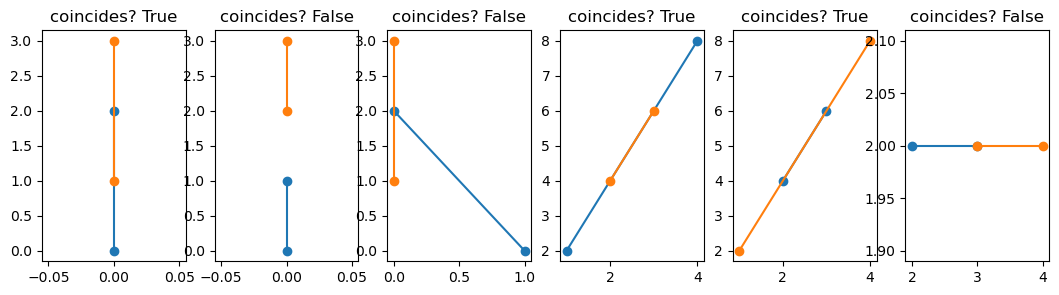

In [15]:
if visual:
    fig, axs = plt.subplots(1,len(points), figsize=(13,3))
    
    for pp, point in enumerate(points):    
        
        a,b,c,d = point
        coincide = lines_coincide(np.array(a),np.array(b),np.array(c),np.array(d))
    
        axs[pp].plot([a[0], b[0]], [a[1], b[1]], 'o-')
        axs[pp].plot([c[0], d[0]], [c[1], d[1]], 'o-')
        axs[pp].set_title(f"coincides? {coincide}")
    
    plt.show()

## Lines intersect

In [16]:
a = np.array([-1, 0])
b = np.array([ 1, 0])
c = np.array([ 0, 1])
d = np.array([ 0,-1])


intersected = check_intersection(a,b,c,d)
print(intersected)

(True, 0)


## polygon rotation and translation

[array([10,  8]), array([ 9, 12]), array([6, 6])]
[np.float64(102.52880770915151), np.float64(40.60129464500448), np.float64(36.86989764584403)]


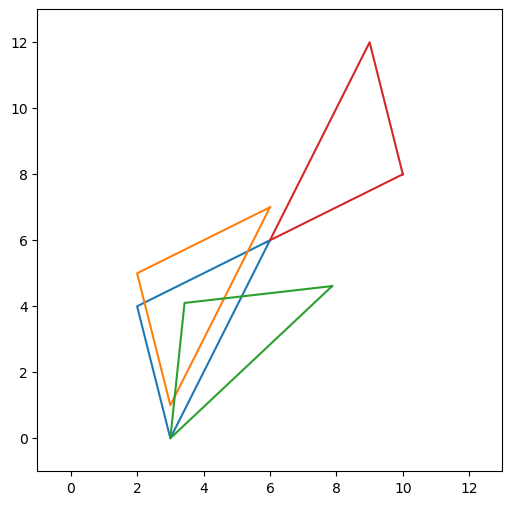

In [27]:
vertices = [[6,6], [3,0], [2,4]]
poly1 = Polygon(vertices.copy())
poly2 = Polygon(vertices.copy())
poly3 = Polygon(vertices.copy())
poly4 = Polygon(vertices.copy())

poly2.translate(np.array([0,1]))
poly3.rotate_around_point(20,poly3.vertices[1])
poly4.reflect()
print(poly4.vertices)
print(poly4.angles)


fig, axs = plt.subplots(1,1,figsize=(6,6))
for poly in [poly1, poly2, poly3, poly4]:
    axs.plot(poly.verticese_x, poly.verticese_y)

axs.set_ylim([-1,13])
axs.set_xlim([-1,13])
plt.show()

## copy into place

[array([4, 5]), array([2, 4]), array([3, 0])]
[array([9, 0]), array([10,  4]), array([8, 5])]


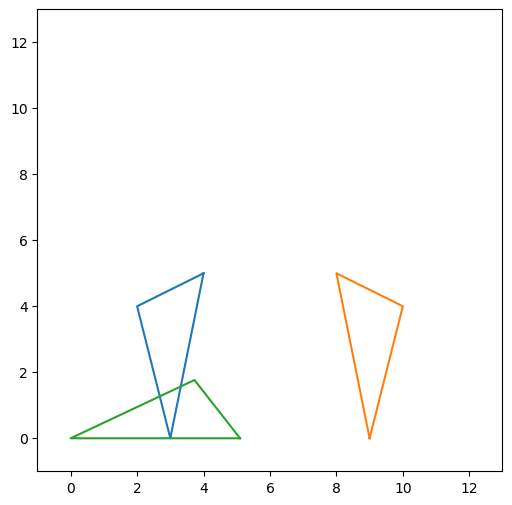

In [18]:
vertices = [[4,5], [2,4], [3,0]]
poly = Polygon(vertices.copy())
poly1 = Polygon(vertices.copy())
poly1.reflect()

print(poly.vertices)
print(poly1.vertices)
node = Node([0,0], 0, 90)

vv = 2
polyc = copy_into_place(poly, vv, node)

fig, axs = plt.subplots(1,1,figsize=(6,6))
for pol in [poly, poly1, polyc]:
    axs.plot(pol.verticese_x, pol.verticese_y)

axs.set_ylim([-1,13])
axs.set_xlim([-1,13])
plt.show()

## Is inside

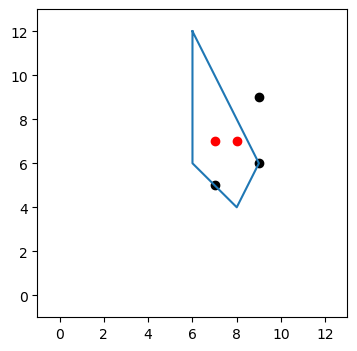

In [18]:
poly = Polygon([[6,12], [6,6], [8,4], [9,6]])

rs = [[7,7], [8,7], [9,6], [7,5], [9,9]]

fig, axs = plt.subplots(1,1,figsize=(4,4))
for r in rs:
    is_inside = poly.is_inside(np.array(r))
    
    color = "k"
    if is_inside:
        color = "r"
    
    
    axs.scatter(*r, c=color)

axs.plot(poly.verticese_x, poly.verticese_y)
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])
plt.show()

## Polygon intersection

In [239]:
poly1, poly2 = Polygon([[1,0], [4,0], [2,4]]), Polygon([[6,0], [2,9], [2,0]])
isect1 = shape1_intersects_shape2(poly1, poly2) 
print("----- isect1: ", isect1)
isect2 = shape1_intersects_shape2(poly2, poly1)
print("----- isect2: ", isect2)


entered shape1 intersects shape2
vertices:  [array([1, 0]), array([4, 0]), array([2, 4])]
basis vectors [ 0 -3] [3 0]
other_vertex:  [6 0] dist:  0
other_vertex:  [2 9] dist:  -27
[3 0] False
basis vectors [4 2] [-2  4]
other_vertex:  [6 0] dist:  24
other_vertex:  [2 9] dist:  26
other_vertex:  [2 0] dist:  8
[-2  4] False
basis vectors [-4  1] [-1 -4]
other_vertex:  [6 0] dist:  -24
[-1 -4] False
----- isect1:  True
entered shape1 intersects shape2
vertices:  [array([6, 0]), array([2, 9]), array([2, 0])]
basis vectors [9 4] [-4  9]
other_vertex:  [1 0] dist:  9
[-4  9] False
basis vectors [-9  0] [ 0 -9]
other_vertex:  [1 0] dist:  -9
other_vertex:  [4 0] dist:  -36
[ 0 -9] False
basis vectors [ 0 -4] [4 0]
other_vertex:  [1 0] dist:  0
other_vertex:  [4 0] dist:  0
other_vertex:  [2 4] dist:  -16
[4 0] False
----- isect2:  True


In [245]:
poly_pairs = [[Polygon([[0,0], [3,0], [2,4]]), Polygon([[3,1], [3,7], [2,5]])],
              [Polygon([[0,0], [3,0], [2,4]]), Polygon([[3,0], [3,6], [2,4]])],
              [Polygon([[0,0], [4,0], [2,4]]), Polygon([[3,0], [3,6], [2,4]])],
              [Polygon([[1,0], [4,0], [2,4]]), Polygon([[6,0], [2,4], [2,0]])],
              [Polygon([[1,0], [4,0], [2,4]]), Polygon([[6,0], [2,9], [2,0]])],
              [Polygon([[5,0], [2,8], [2,0]]), Polygon([[6,0], [2,9], [2,0]])],
              [Polygon([[1,0], [3,0], [2,3]]), Polygon([[2,0], [5,0], [3,5]])],
              [Polygon([[0,0], [4,0], [2,4]]), Polygon([[0,0], [4,0], [2,4]])],
              [Polygon([[0,0], [4,0], [2,4]]), Polygon([[3,2], [3,6], [2,4]])],
              [Polygon([[1,1], [1,0], [0,1]]), Polygon([[2,2], [2,0], [0,2]])],
              [Polygon([[1,1], [1,0], [0,1]]), Polygon([[0,0], [3,0], [0,3]])],
              [Polygon([[1,1], [1,2], [2,1]]), Polygon([[0,0], [5,0], [0,5]])],
              [Polygon([[0,0], [5,0], [0,5]]), Polygon([[1,1], [1,2], [2,1]])],
              [Polygon([[6,12], [6,6], [8,4], [9,6]]), Polygon([[9,6], [12,6], [12,8]])]]

results = [False, False, True, True, True, True, True, True, False, False, True, True, True, False]

test_results = [shapes_intersect(pair[0], pair[1]) == result for pair, result in zip(poly_pairs, results)]

print("all passed? ", False not in test_results)

all passed?  True


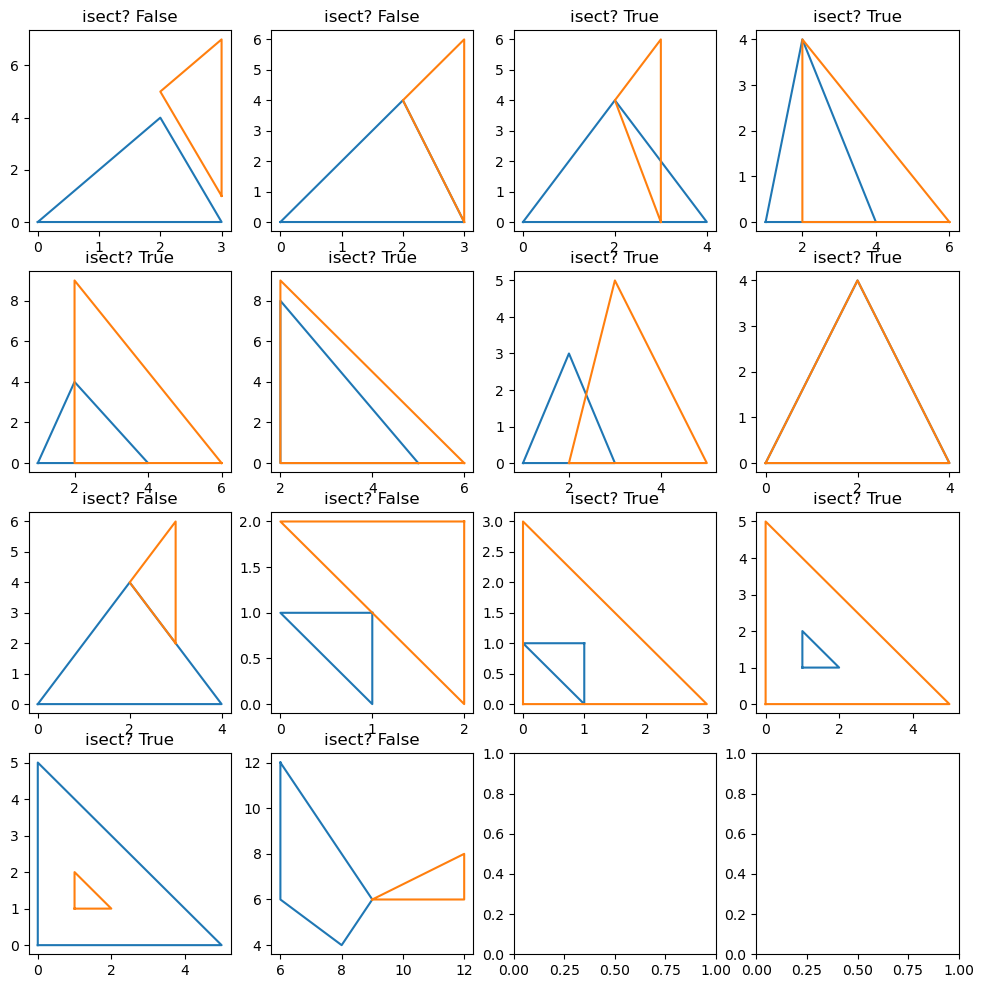

In [246]:
if visual:
    Nrows = len(poly_pairs)//4+1
    
    fig, axs = plt.subplots(Nrows,4,figsize=(12,3*Nrows))
    
    all_passed = True
    for pp,(pair, result) in enumerate(zip(poly_pairs, results)):
        # print("---- New test", pp)
        ax = axs[pp//4, pp%4]
        poly1, poly2 = pair
        intersect = shapes_intersect(poly1, poly2)
        isect1 = shape1_intersects_shape2(poly1, poly2) 
        isect2 = shape1_intersects_shape2(poly2, poly1)
        if intersect != result:
            all_passed = False
    
        ax.set_title(f"isect? {isect1} {isect2}")
        ax.set_title(f"isect? {intersect}")
        for poly in [poly1, poly2]:
            ax.plot(poly.verticese_x, poly.verticese_y)
        
    plt.show()

## Test vertex-vertex methods

In [21]:
N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)
nodes = [N1, N2, N3, N4]

poly1  = Polygon([[0,0], [3,0], [2,4]])
poly2  = Polygon([[3,0], [3,6], [2,4]])
poly3  = Polygon([[0,0], [4,8], [2,10]])
poly4  = Polygon([[0,0], [2,10], [0,12]])
polys = [poly1, poly2, poly3, poly4]

state = State(nodes, [], copy.deepcopy(polys))

state.print()

Nodes:
  [0.0 0.0] 0.0 90.0
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:


Considering vertex 1 of polygon [array([0, 0]), array([3, 0]), array([2, 4])] to node [12  0] 90.0 90.0
Polygon was moved into place. New vertices:
[array([9.0895725 , 0.72760688]), array([12.,  0.]), array([12.        ,  4.12310563])]


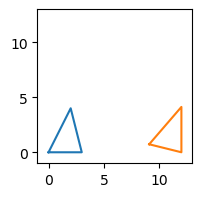

Shape fits inside
No intersection found
nodes to ignore:  [1]
vertices to ignore:  [1]
[12  0] 165.96375653207355 14.036243467926468


In [22]:
poly = state.shapes_left[0]
node = state.nodes[1]
vv = 1
print(f"Considering vertex {vv} of polygon {poly.vertices} to node {node.position} {node.angle_init:1.1f} {node.angle_opening:1.1f}")

polyc = copy_into_place(poly, vv, node)

print("Polygon was moved into place. New vertices:")
print(polyc.vertices)

fig, axs = plt.subplots(1,1,figsize=(2,2))
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])
axs.plot(poly.verticese_x, poly.verticese_y)
axs.plot(polyc.verticese_x, polyc.verticese_y)
plt.show()


if polyc.is_outside_bounds():
    print("Shape out of bounds")
else: 
    print("Shape fits inside")
if intersects_others(polyc, state.shapes_used):
    print("Shapes intersect")
else:
    print("No intersection found")


new_nodes_v, nodes_to_ignore, vertices_to_ignore = new_nodes_from_vertices(polyc, state.nodes)

print("nodes to ignore: ", nodes_to_ignore)
print("vertices to ignore: ", vertices_to_ignore)
for noden in new_nodes_v:
    print(noden.position, noden.angle_init, noden.angle_opening)

## Test node-edge methods

---- Current state ----
Nodes:
  [0.0 0.0] 0.0 90.0
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:

---- Next state ----
Nodes:
  [0.0 0.0] 63.4 26.6
  [3.0 0.0] 0.0 104.0
  [2.0 4.0] -76.0 319.4
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:
   [0.0,0.0]    [3.0,0.0]    [2.0,4.0] 


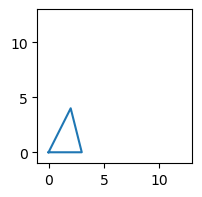

In [23]:
N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)
nodes = [N1, N2, N3, N4]

poly1  = Polygon([[0,0], [3,0], [2,4]])
poly2  = Polygon([[3,0], [3,6], [2,4]])
poly3  = Polygon([[0,0], [4,8], [2,10]])
poly4  = Polygon([[0,0], [2,10], [0,12]])
polys = [poly1, poly2, poly3, poly4]

state = State(nodes, [], copy.deepcopy(polys))

print("---- Current state ----")
state.print()
print()

next_states = produce_next_states(state)
# next_states = produce_next_states(next_states[0])
next_state = next_states[0]
print("---- Next state ----")
next_state.print()


fig, axs = plt.subplots(1,1,figsize=(2,2))
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])
for poly in next_state.shapes_used:
    axs.plot(poly.verticese_x, poly.verticese_y)

plt.show()

Considering vertex 0 of polygon [array([3, 0]), array([3, 6]), array([2, 4])] to node [0 0] 63.4 26.6
Polygon was moved into place. New vertices:
[array([0., 0.]), array([2.68328157, 5.36656315]), array([0.89442719, 4.02492236])]


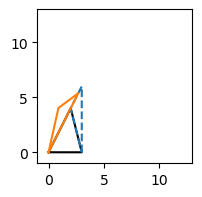

Shape fits inside
No intersection found
   node [2. 4.] -76.0 139.4
nodes_to_igonre [2]


In [24]:
# Initialize the state
poly = next_state.shapes_left[0]
node = next_state.nodes[0]
vv = 0
print(f"Considering vertex {vv} of polygon {poly.vertices} to node {node.position} {node.angle_init:1.1f} {node.angle_opening:1.1f}")



# Move proposed polygon into place
polyc = copy_into_place(poly, vv, node)
print("Polygon was moved into place. New vertices:")
print(polyc.vertices)

fig, axs = plt.subplots(1,1,figsize=(2,2))
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])

for pol in next_state.shapes_used:
    axs.plot(pol.verticese_x, pol.verticese_y, 'k')
    
axs.plot(poly.verticese_x, poly.verticese_y, '--')
axs.plot(polyc.verticese_x, polyc.verticese_y)
plt.show()



# Check if it fits
if polyc.is_outside_bounds():
    print("Shape out of bounds")
else: 
    print("Shape fits inside")
if intersects_others(polyc, state.shapes_used):
    print("Shapes intersect")
else:
    print("No intersection found")

new_nodes, nodes_to_ignore = new_nodes_from_edges_and_nodes(polyc, next_state.nodes)
for noden in new_nodes:
    print(f"   node {noden.position} {noden.angle_init:1.1f} {noden.angle_opening:1.1f}")
print("nodes_to_igonre", nodes_to_ignore)

## Test vertex-edge methods

---- Current state ----
Nodes:
  [0.0 0.0] 0.0 90.0
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:

---- Next state ----
Nodes:
  [0.0 0.0] 63.4 26.6
  [3.0 0.0] 0.0 104.0
  [2.0 4.0] -76.0 319.4
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:
   [0.0,0.0]    [3.0,0.0]    [2.0,4.0] 


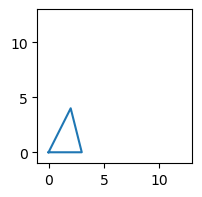

In [25]:
N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)
nodes = [N1, N2, N3, N4]

poly1  = Polygon([[0,0], [3,0], [2,4]])
poly2  = Polygon([[3,0], [3,6], [2,4]])
poly3  = Polygon([[0,0], [4,8], [2,10]])
poly4  = Polygon([[0,0], [2,10], [0,12]])
polys = [poly1, poly2, poly3, poly4]

state = State(nodes, [], copy.deepcopy(polys))

print("---- Current state ----")
state.print()
print()

next_states = produce_next_states(state)
next_state = next_states[0]
print("---- Next state ----")
next_state.print()


fig, axs = plt.subplots(1,1,figsize=(2,2))
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])
for poly in next_state.shapes_used:
    axs.plot(poly.verticese_x, poly.verticese_y)

plt.show()

Considering vertex 0 of polygon [array([3, 0]), array([3, 6]), array([2, 4])] to node [0 0] 63.4 26.6
Polygon was moved into place. New vertices:
[array([0., 0.]), array([2.68328157, 5.36656315]), array([0.89442719, 4.02492236])]


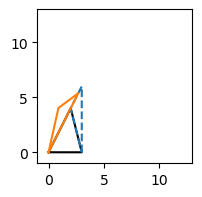

Shape fits inside
No intersection found
Checking coinciding vertices
   node [0 0] 77.5 12.5
nodes to ignore after considering vertex coincidence: [0]
polyc vertex on other_poly edge []
other_poly vertex on polyc edge [2]
Checking vertices intersecting edges:
   node [2. 4.] -76.0 139.4
vertices_to_ignore: [0]
Finally
   node [0 0] 77.5 12.5
   node [2. 4.] -76.0 139.4
   node [2.68328157 5.36656315] -116.6 333.4
   node [0.89442719 4.02492236] 36.9 220.6
   node [3. 0.] 0.0 104.0
   node [2. 4.] -76.0 319.4
   node [12  0] 90.0 90.0
   node [ 0 12] 270.0 90.0
   node [12 12] 180.0 90.0


In [26]:
# Initialize the state
poly = next_state.shapes_left[0]
node = next_state.nodes[0]
vv = 0
print(f"Considering vertex {vv} of polygon {poly.vertices} to node {node.position} {node.angle_init:1.1f} {node.angle_opening:1.1f}")



# Move proposed polygon into place
polyc = copy_into_place(poly, vv, node)
print("Polygon was moved into place. New vertices:")
print(polyc.vertices)

fig, axs = plt.subplots(1,1,figsize=(2,2))
axs.set_xlim([-1,13])
axs.set_ylim([-1,13])

for pol in next_state.shapes_used:
    axs.plot(pol.verticese_x, pol.verticese_y, 'k')
    
axs.plot(poly.verticese_x, poly.verticese_y, '--')
axs.plot(polyc.verticese_x, polyc.verticese_y)
plt.show()



# Check if it fits
if polyc.is_outside_bounds():
    print("Shape out of bounds")
else: 
    print("Shape fits inside")
if intersects_others(polyc, state.shapes_used):
    print("Shapes intersect")
else:
    print("No intersection found")


new_nodes_v, nodes_to_ignore, vertices_to_ignore = new_nodes_from_vertices(polyc, next_state.nodes)
print("Checking coinciding vertices")
for noden in new_nodes_v:
    print(f"   node {noden.position} {noden.angle_init:1.1f} {noden.angle_opening:1.1f}")
print("nodes to ignore after considering vertex coincidence:", nodes_to_ignore)

# Check if the vertices of polyc intersect the edges of other_poly, and return
# the new nodes that result from that intersection. and vice-versa
new_nodes_e = []
other_poly = next_state.shapes_used[0]
new, ignore = new_nodes_from_edges(polyc, other_poly)
vertices_to_ignore += ignore
print("polyc vertex on other_poly edge", ignore)
new_nodes_e += new

new, ignore = new_nodes_from_edges(other_poly, polyc)
print("other_poly vertex on polyc edge", ignore)
new_nodes_e += new

print("Checking vertices intersecting edges:")
for noden in new_nodes_e:
    print(f"   node {noden.position} {noden.angle_init:1.1f} {noden.angle_opening:1.1f}")
print("vertices_to_ignore:", vertices_to_ignore)

# Do the same for the bounding box
# new, ignore = new_nodes_from_edges(polyc, next_state.bounding_box)
# vertices_to_ignore += ignore
# new_nodes_e += new

# new, ignore = new_nodes_from_edges(next_state.bounding_box, polyc)
# new_nodes_e += new


new_nodes = new_nodes_v + new_nodes_e



for vv in range(polyc.Nsides):
    if vv not in vertices_to_ignore:
        vertex      = polyc.vertices[vv]
        prev_vertex = polyc.vertices[(vv-1)%polyc.Nsides]
        
        edge = prev_vertex - vertex
        θ = float(np.arctan2(edge[1], edge[0])/np.pi*180)
        ψ = float(poly.angles[vv])
        new_nodes.append(Node(vertex, θ, 360-ψ))

for nn in range(len(next_state.nodes)):
    if nn not in nodes_to_ignore:
        new_nodes.append(next_state.nodes[nn])

print("Finally")
for noden in new_nodes: 
    print(f"   node {noden.position} {noden.angle_init:1.1f} {noden.angle_opening:1.1f}")

# Ostomachion polygons

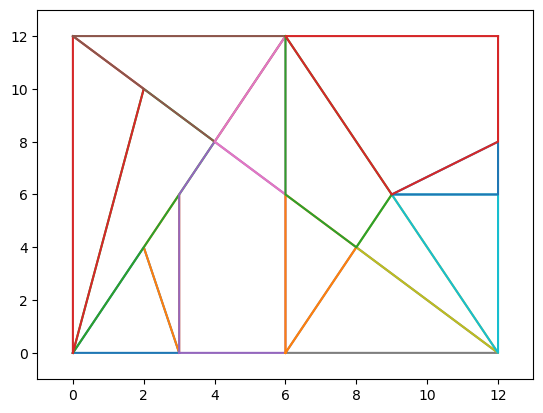

In [17]:
# All points must be anti-clockwise
poly1  = Polygon([[0,0], [3,0], [2,4]])
poly2  = Polygon([[3,0], [3,6], [2,4]])
poly3  = Polygon([[0,0], [4,8], [2,10]])
poly4  = Polygon([[0,0], [2,10], [0,12]])
poly5  = Polygon([[3,0], [6,0], [6,6], [4,8], [3,6]])
poly6  = Polygon([[0,12], [4,8], [6,12]])
poly7  = Polygon([[6,6], [6,12], [4,8]])
poly8  = Polygon([[6,0], [12,0], [8,4]])
poly9  = Polygon([[9,6], [8,4], [12,0]])
poly10 = Polygon([[9,6], [12,0], [12,6]])
poly11 = Polygon([[9,6], [12,6], [12,8]])
poly12 = Polygon([[6,0], [8,4], [6,6]])
poly13 = Polygon([[6,12], [6,6], [8,4], [9,6]])
poly14 = Polygon([[12,12], [6,12], [9,6], [12,8]])

polys_osto = [poly1, poly2, poly3, poly4, poly5, poly6, poly7, poly8, poly9, poly10, poly11, poly12, poly13, poly14]


for poly in polys_osto:
    plt.plot(poly.verticese_x, poly.verticese_y)

plt.ylim([-1,13])
plt.xlim([-1,13])
plt.show()

# Algo test

In [19]:
select_states = [0,2,0,2,13,7,4,6,7,3,3,1,0]
# select_states = [0,2,0,2,12,4]

is inverting
after copy into place
[0. 0.]
[4.12310563e+00 8.88178420e-16]
[3.39549875 2.9104275 ]
after copy into place
[1. 4.]
[0. 0.]
[3. 0.]
after copy into place
[4.47213595 0.        ]
[1.34164079 2.68328157]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[3. 0.]
[2. 4.]
after copy into place
[0.72760688 2.9104275 ]
[0. 0.]
[ 4.12310563e+00 -8.88178420e-16]
after copy into place
[4.47213595 0.        ]
[3.13049517 2.68328157]
[0. 0.]
is inverting
after copy into place
[2. 1.]
[0. 0.]
[ 6.0000000e+00 -3.6739404e-16]
after copy into place
[ 4.12310563e+00 -3.33066907e-16]
[5.820855   1.45521375]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[6.0000000e+00 3.6739404e-16]
[4. 1.]
after copy into place
[5.36656315 2.68328157]
[0. 0.]
[2.23606798 0.        ]
is inverting
after copy into place
[0. 0.]
[ 2.82842712e+00 -2.22044605e-16]
[5.65685425 8.48528137]
after copy into place
[ 1.01980390e+01 -3.10862447e-15]
[8.62910995 2.35339362]
[0. 0.]
is not inverting
after co

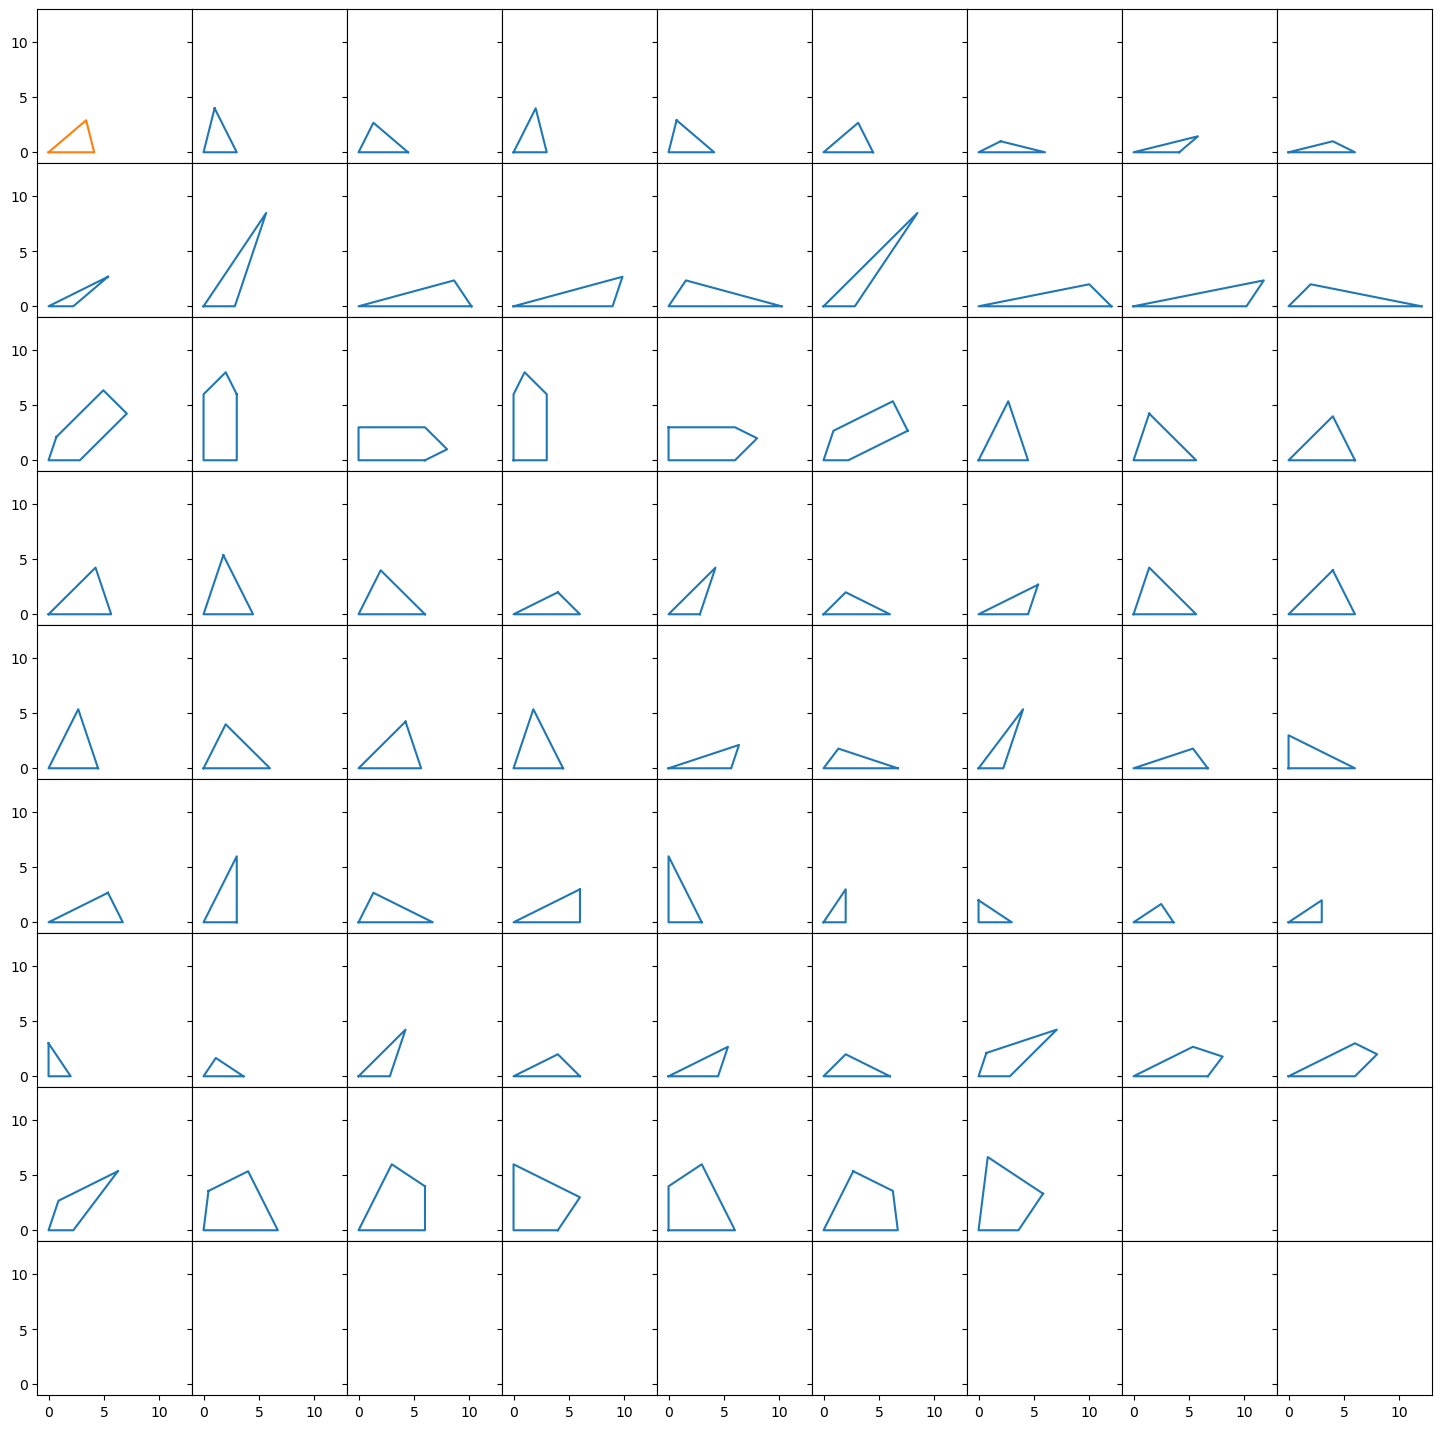

is inverting
after copy into place
[0.86772183 2.06083935]
[0. 0.]
[4.55553961 3.90474824]
after copy into place
[3.13049517 2.68328157]
[3.47248204 4.89304287]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[4.55553961 3.90474824]
[2.38623504 3.3624221 ]
after copy into place
[2.328342   5.52981225]
[0. 0.]
[1.69774938 1.45521375]
is inverting
after copy into place
[7.74292846 6.63679583]
[5.02014043 7.40257996]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[6.7909975 5.820855 ]
[5.72384075 8.44023975]
is inverting
after copy into place
[0. 0.]
[2.14750197 1.84071597]
[ 0.92035799 11.96465383]
after copy into place
[9.11107923 7.80949648]
[6.29098328 8.02642694]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[7.74292846 6.63679583]
[7.40257996 9.44467098]
after copy into place
[9.11107923 7.80949648]
[0.21693046 2.82009595]
[0. 0.]
is inverting
is not inverting
is inverting
after copy into place
[4.55553961 3.90474824]
[0.43386092 5.6401919 ]
[0. 0.]
is not in

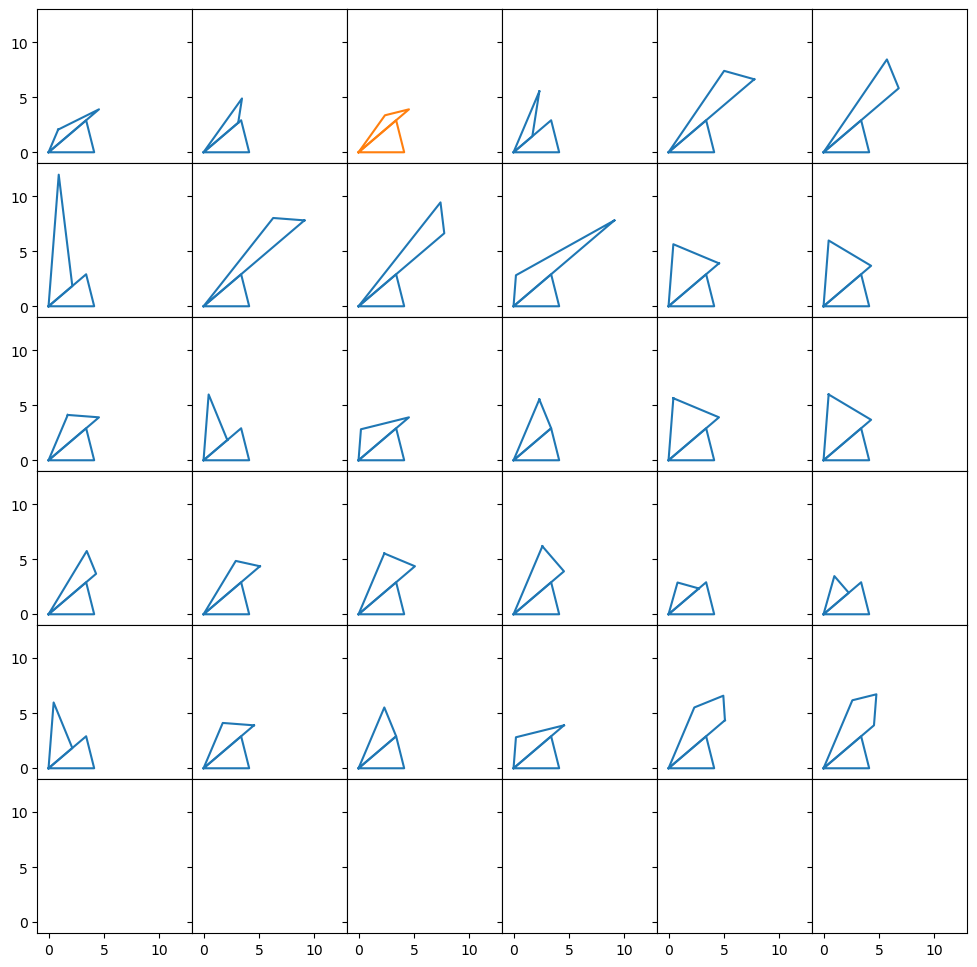

is inverting
after copy into place
[5.90208455 8.31657369]
[3.07486223 8.39912033]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[5.17647059 7.29411765]
[3.50588235 9.57647059]
is inverting
after copy into place
[6.94496407 9.78608574]
[4.15645577 9.31256546]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[5.90208455 8.31657369]
[ 4.89088825 10.95806608]
is inverting
is not inverting
is inverting
is not inverting
is inverting
after copy into place
[0.68397373 4.41952259]
[0. 0.]
[3.47248204 4.89304287]
is not inverting
after copy into place
[0.91764706 5.92941176]
[0. 0.]
[2.58823529 3.64705882]
is inverting
is not inverting
is inverting
after copy into place
[0. 0.]
[3.27388746 4.61320506]
[1.9531715  6.41756349]
is not inverting
after copy into place
[3.88235294 5.47058824]
[1.64705882 5.41176471]
[0. 0.]
is inverting
after copy into place
[0.91764706 5.92941176]
[0. 0.]
[3.88235294 5.47058824]
is not inverting
after copy into place
[1.0259606  6.62928389]
[0. 0.]
[3

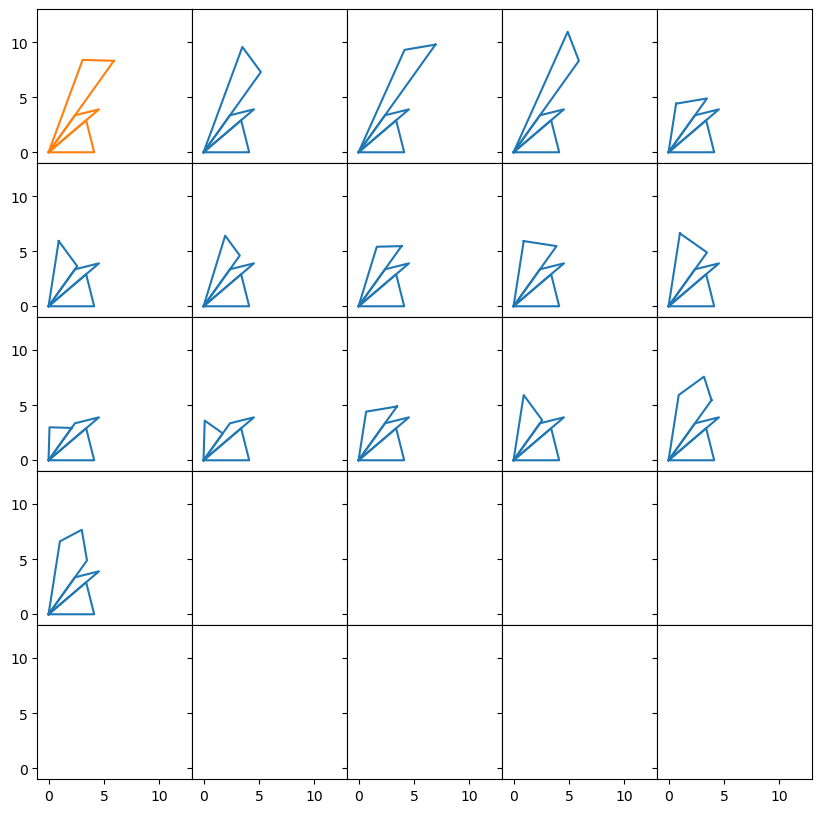

is inverting
after copy into place
[ 4.12536058 11.2686024 ]
[ 1.55970009 10.0780621 ]
[0. 0.]
is not inverting
after copy into place
[0. 0.]
[3.50588235 9.57647059]
[ 1.83529412 11.85882353]
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
after copy into place
[0. 0.]
[1.94471363 5.31207011]
[0.19577654 6.70534649]
is not inverting
after copy into place
[2.30614667 6.29934024]
[0.16509327 5.65444464]
[0. 0.]
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
number of options:  4
selecting state  2
Nodes:
  [0.0 0.0] 88.3 1.7
  [1.9 5.3] -110.1 0.0
  [1.9 5.3] 69.9 71.6
  [0.2 6.7] -38.5 306.9
  [5.9 8.3] -125.4 303.7
  [3.1 8.4] -1.7 251.6
  [2.4 3.4] 14.0 40.6
  [4.6 3.9] -139.4 333.4
  [3.4 2.9] -76.0 116.6
  [4.1 0.0] -0.0 104.0
  [12.0 0.0] 90.0 90.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0


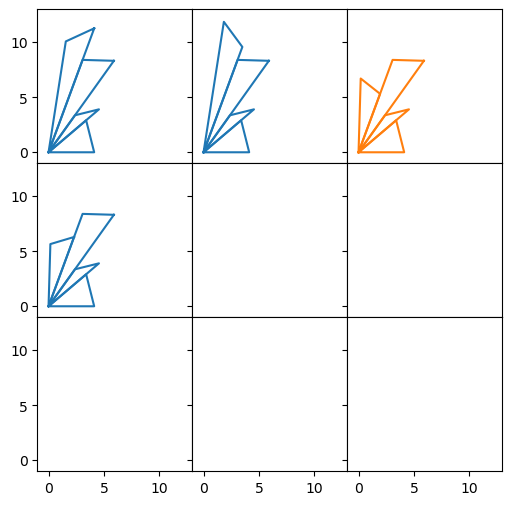

is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
is inverting
is not inverting
number of options:  0


IndexError: list index out of range

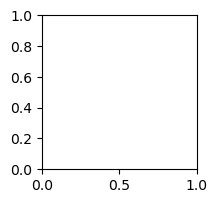

In [20]:
N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)

shapes_left = [copy.deepcopy(poly) for poly in polys_osto]
state = State([N1, N2, N3, N4], [], shapes_left)

for select_state in select_states:
    next_states = produce_next_states(state)
    
    num_options = len(next_states)
    print("number of options: ", num_options)
    sq = int(np.sqrt(len(next_states))+0.01)+1
    Ncols = sq
    Nrows = sq
    
    fig, axs = plt.subplots(Nrows, Ncols,figsize=(2*Ncols,2*Nrows), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.0, hspace=0.0)
    
    state = next_states[select_state]
    for i,next_state in enumerate(next_states):
        color = 'C0'
        if i==select_state: 
            print("selecting state ", i)
            color = 'C1'
            next_state.print()
        ax = axs[i//Nrows, i%Ncols]
        
        ax.set_xlim([-1,13])
        ax.set_ylim([-1,13])
        for poly in next_state.shapes_used:
            ax.plot(poly.verticese_x, poly.verticese_y, c=color)
    plt.show()

In [116]:
next_states[2].print()

Nodes:
  [9.3 5.4] 116.6 135.0
  [7.5 0.0] 71.6 108.4
  [9.0 6.0] 0.0 296.6
  [12.0 6.0] 90.0 90.0
  [4.0 8.0] -116.6 180.0
  [6.0 12.0] -116.6 116.6
  [2.0 4.0] -76.0 139.4
  [3.0 0.0] 0.0 104.0
  [12.0 12.0] 180.0 90.0
Shapes used:
   [0.0,0.0]    [3.0,0.0]    [2.0,4.0] 
   [0.0,0.0]    [4.0,8.0]    [2.0,10.0] 
   [0.0,0.0]    [2.0,10.0]    [0.0,12.0] 
   [0.0,12.0]    [4.0,8.0]    [6.0,12.0] 
   [9.0,6.0]    [12.0,0.0]    [12.0,6.0] 
   [12.0,0.0]    [9.3,5.4]    [7.5,0.0] 


## Manual

In [188]:
tol = 1e-8
select_states = [0,2,0,2,12]#,4]
select_states = [0,2,0,2,12,4,2,5,5,3]#,0]

N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)

shapes_left = [copy.deepcopy(poly) for poly in polys_osto]
state = State([N1, N2, N3, N4], [], shapes_left)

for select_state in select_states:
    next_states = produce_next_states(state)
    state = next_states[select_state]

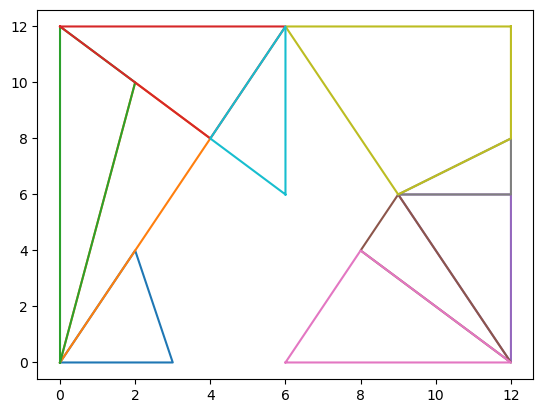

next node:  [ 6. 12.] -90.0 26.56505117707799
considering poly [array([ 6, 12]), array([6, 6]), array([8, 4]), array([9, 6])]
considering angle 0 26.56505117707799
Poly after moving
6.0000000000,12.0000000000
6.0000000000,6.0000000000
8.0000000000,4.0000000000
9.0000000000,6.0000000000


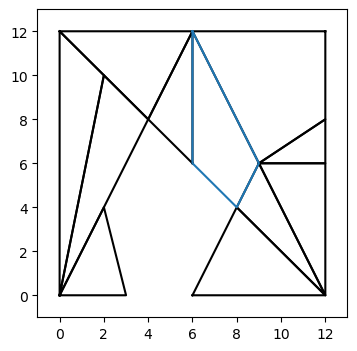

intersects shape  7
9.0000000000,6.0000000000
12.0000000000,6.0000000000
12.0000000000,8.0000000000
Shapes intersect
Checking vertex of polyc:  0 [ 6. 12.]
   Intersection of poly vertex and nodes
ignore:  [1]
   Intersection of poly vertex and other poly edges
    [ 6. 12.] -63.43494882292201 63.43494882292201
    [ 6. 12.] 180.0 90.0
Checking vertex of polyc:  1 [6. 6.]
   Intersection of poly vertex and nodes
    [6. 6.] 135.0 180.0
ignore:  [0]
   Intersection of poly vertex and other poly edges
Checking vertex of polyc:  2 [8. 4.]
   Intersection of poly vertex and nodes
    [8. 4.] 135.0 108.43494882292204
ignore:  [5]
   Intersection of poly vertex and other poly edges
Checking vertex of polyc:  3 [9. 6.]
   Intersection of poly vertex and nodes
ignore:  [3]
   Intersection of poly vertex and other poly edges
Intersection of polyc edges and other nodes
ignore:  []


In [205]:

node = state.get_next_node()
print("next node: ", node.position, node.angle_init, node.angle_opening)

p = 3
poly = state.shapes_left[p]
print("considering poly", poly.vertices)

vv = 0
poly_vertex_angle = poly.angles[vv]
print("considering angle", vv, poly_vertex_angle)

# Check if the new proposed shape will fit
if poly_vertex_angle > node.angle_opening + tol:
    print("angle too wide")

polyc = copy_into_place(poly, vv, node)
print("Poly after moving")
for vertex in polyc.vertices:
    print(f"{vertex[0]:10.10f},{vertex[1]:10.10f}")

fig, axs = plt.subplots(1,1,figsize=(4,4))
for poly in state.shapes_used:
    axs.plot(poly.verticese_x, poly.verticese_y, c='k')
axs.plot(polyc.verticese_x, polyc.verticese_y)
axs.set_ylim([-1,13])
axs.set_xlim([-1,13])
plt.show()

if polyc.is_outside_bounds(): print("Shape out of bounds")
if intersects_others(polyc, state.shapes_used): print("Shapes intersect")

# Check if the new vertices can form new nodes or modify existing ones
# Check if this vertex coincides with any existing node
for vi in range(polyc.Nsides):
    print("Checking vertex of polyc: ", vi, polyc.vertices[vi])
    new, ignore = new_nodes_from_vertex(polyc, vi, state.nodes)
    print("   Intersection of poly vertex and nodes")
    for noden in new:
        print("   ", noden.position, noden.angle_init, noden.angle_opening)
    print("ignore: ", ignore)
    
    
    # Check if the vertex of poly intersect the edges of any other poly, and return
    # the new nodes that result from that intersection
    print("   Intersection of poly vertex and other poly edges")
    for other_poly in state.shapes_used + [state.bounding_box]:
        new = new_nodes_from_edges_and_v(polyc, vi, other_poly)
        for noden in new:
            print("   ", noden.position, noden.angle_init, noden.angle_opening)


# Update existing nodes that intersect edges of polyc
print("Intersection of polyc edges and other nodes")
new, ignore = new_nodes_from_edges_and_nodes(polyc, state.nodes)
for noden in new:
    print(noden.position, noden.angle_init, noden.angle_opening)
print("ignore: ", ignore)


## Automatic

In [62]:
N1 = Node([ 0, 0],   0, 90)
N2 = Node([12, 0],  90, 90)
N4 = Node([12,12], 180, 90)
N3 = Node([ 0,12], 270, 90)

shapes_left = [copy.deepcopy(poly) for poly in polys_osto]
state = State([N1, N2, N3, N4], [], shapes_left)
allow_reflection = False

# Do BFS to 2nd level to get an initial set of states to parallelize, then DFS
initial_search_states = [state]
for i in range(3):
    # initial_search_states = produce_next_states(state, allow_reflection)
    # print(len(initial_search_states))
    next_search_states = []
    for next_state in initial_search_states:
        next_search_states += copy.deepcopy(produce_next_states(next_state, allow_reflection))
    initial_search_states = copy.deepcopy(next_search_states)
    
    print(len(initial_search_states))


35
430
3147


In [63]:
staten = initial_search_states[53]
staten.print()
next_states = produce_next_states(staten, allow_reflection)
print(len(next_states))

Nodes:
  [12.0 0.0] 135.0 45.0
  [12.0 6.0] 90.0 153.4
  [10.0 2.0] 63.4 251.6
  [0.0 6.7] -26.6 116.6
  [2.7 5.4] -116.6 270.0
  [2.0 4.0] -76.0 139.4
  [3.0 0.0] 0.0 104.0
  [0.0 12.0] 270.0 90.0
  [12.0 12.0] 180.0 90.0
Shapes used:
   [0.0,0.0]    [3.0,0.0]    [2.0,4.0] 
   [0.0,6.7]    [0.0,0.0]    [2.7,5.4] 
   [12.0,0.0]    [12.0,6.0]    [10.0,2.0] 
12


In [65]:

def iterate(state):
    if len(state.shapes_used)==14: 
        # state_list.append(copy.deepcopy(state))
        # count = len(state_list)
        
        # fig, axs = plt.subplots(1,1,figsize=(4,4))
        # axs.set_xlim([-1,13])
        # axs.set_ylim([-1,13])
        # axs.set_title(f"{count}")
        
        # for poly in state.shapes_used:
        #     axs.plot(poly.verticese_x, poly.verticese_y)
        # plt.show()
        print("found one")
        return [copy.deepcopy(state)]

    
    next_states = produce_next_states(state, allow_reflection)

    complete_list = []
    for next_state in next_states:
        complete_list += iterate(next_state)
    return complete_list


# complete_list = iterate(initial_search_states[53])


In [58]:

for staten in complete_list:
    fig, axs = plt.subplots(1,1,figsize=(4,4))
    axs.set_xlim([-1,13])
    axs.set_ylim([-1,13])
    axs.set_title(f"{count}")
    
    for poly in staten.shapes_used:
        axs.plot(poly.verticese_x, poly.verticese_y)
    plt.show()
    

In [66]:
from multiprocessing import Pool

with Pool(10) as p:
    complete_list = p.map(iterate, initial_search_states)

found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one
found one


In [72]:
pruned = []
for state_list in complete_list:
    if len(state_list) > 0:
        pruned += state_list

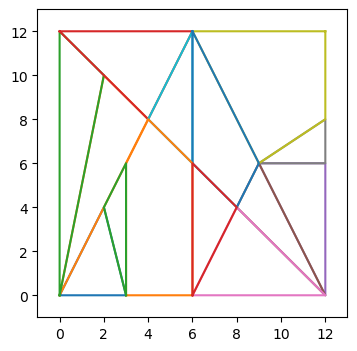

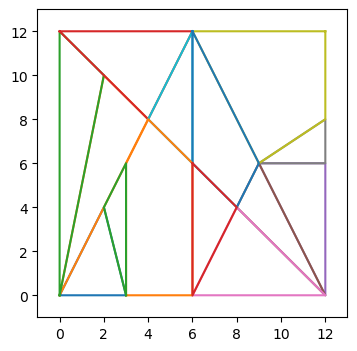

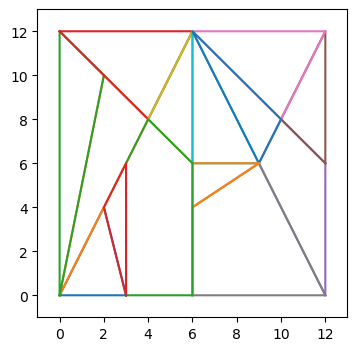

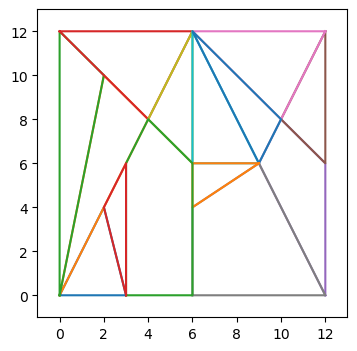

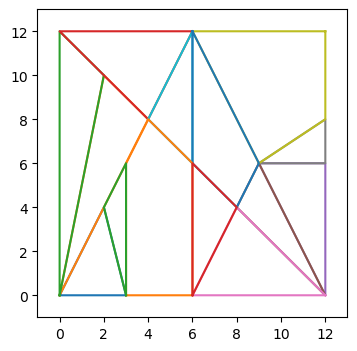

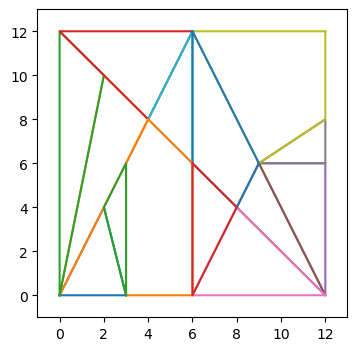

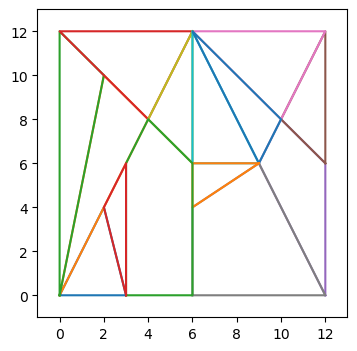

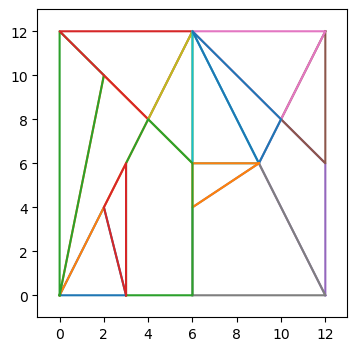

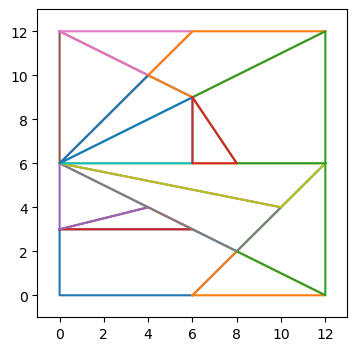

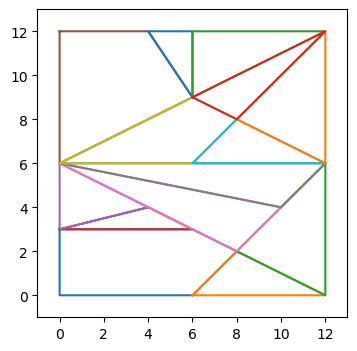

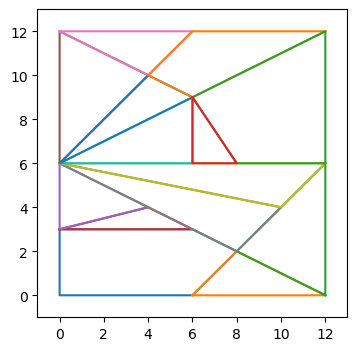

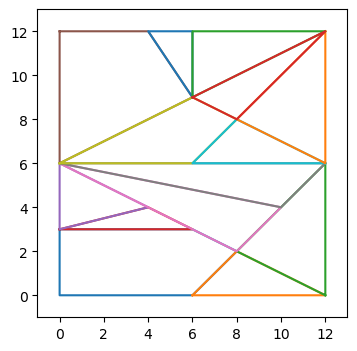

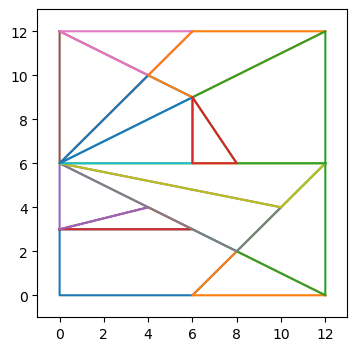

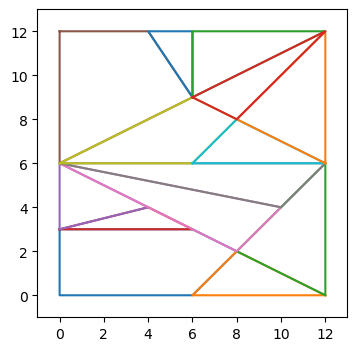

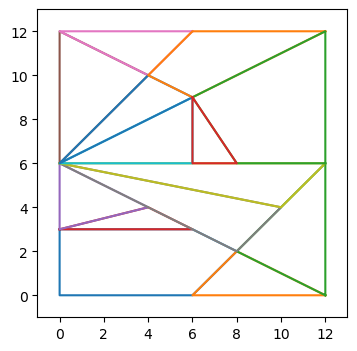

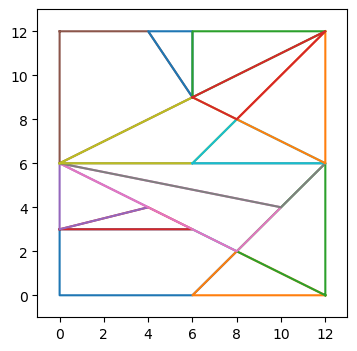

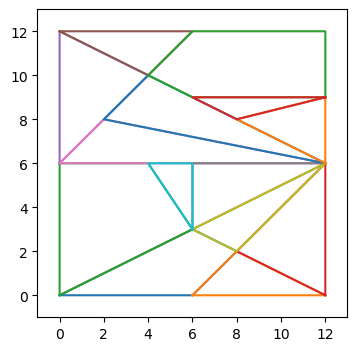

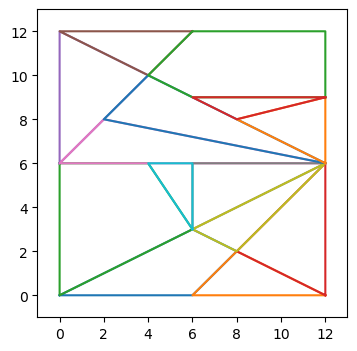

In [75]:

for staten in pruned:
    fig, axs = plt.subplots(1,1,figsize=(4,4))
    axs.set_xlim([-1,13])
    axs.set_ylim([-1,13])
    
    for poly in staten.shapes_used:
        axs.plot(poly.verticese_x, poly.verticese_y)
    plt.show()
    